In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy

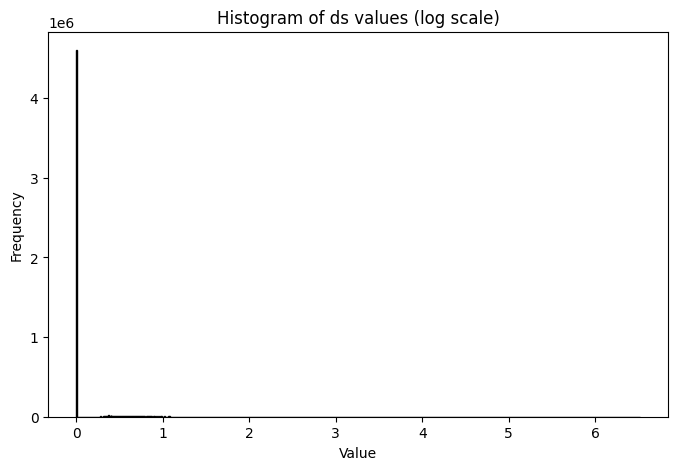

In [41]:
import h5py
import matplotlib.pyplot as plt

ind = 0

with h5py.File("/center/pop_genom/soumick/giudi/onek1k_4DiffAE_top5000genes.h5", "r") as f:
    grp0 = f[list(f.keys())[ind]]
    grp1 = grp0["1"]
    grp2 = grp1["1"]
    ds = grp2["primary"][()]
    # ds = ds / np.max(ds)
    ds_log = np.log(1+ds.flatten())
    ds_log = ds_log / np.max(ds_log)
    plt.figure(figsize=(8, 5))
    plt.hist(ds.flatten(), bins=1000, color='skyblue', edgecolor='black')
    plt.title('Histogram of ds values (log scale)')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()


In [44]:
ds.mean(), np.median(ds), ds.std(), ds.max(), ds.min()

(np.float32(0.16239439),
 np.float32(0.0),
 np.float32(0.46295118),
 np.float32(6.5169544),
 np.float32(0.0))

(np.float32(0.0),
 np.float32(1.0),
 np.float32(0.00023917439),
 np.float32(0.0037026806))

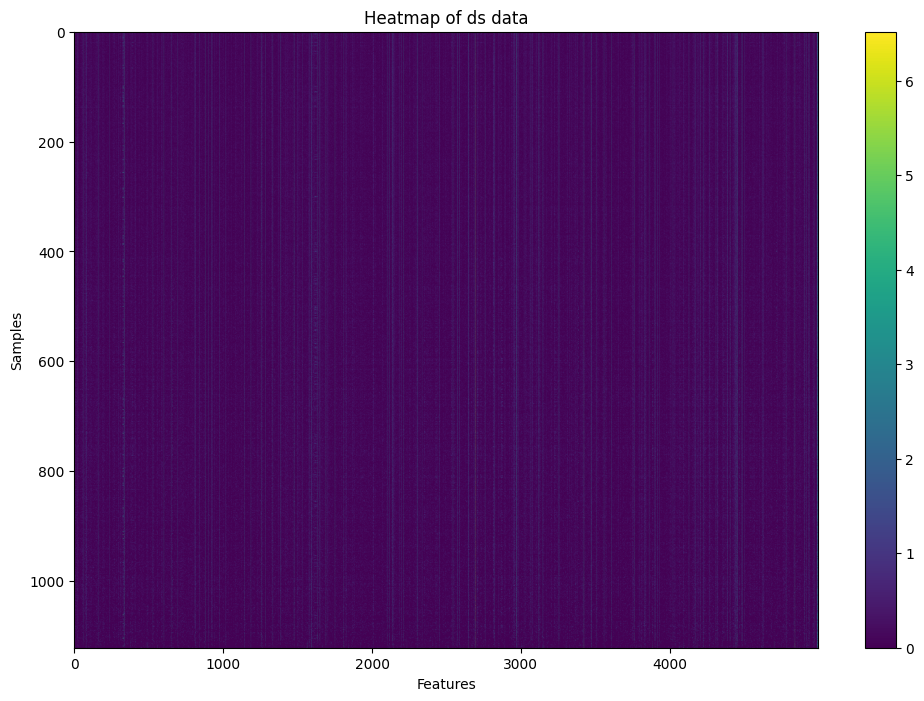

In [43]:


plt.figure(figsize=(12, 8))
plt.imshow((ds).squeeze(), cmap='viridis', aspect='auto')
plt.colorbar()
plt.title('Heatmap of ds data')
plt.xlabel('Features')
plt.ylabel('Samples')
plt.show()

In [2]:
def normalization(x, low=1e-8, high=1):
    MIN = min(x)
    MAX = max(x)
    x = low + (x-MIN)/(MAX-MIN)*(high-low) # zoom to (low, high)
    return x

def fix_sc_normalize_truncate_padding(x, length):
    '''
    x = (num_gene,1)

    '''
    len_x = len(x.X[0])
    tmp = [i for i in x.X[0]]
    tmp = normalization(tmp)
    if len_x >= length: # truncate
        x_value = tmp[:length]
        gene = x.var.iloc[:length]['my_Id'].astype(int).values.tolist()
        mask = np.full(length, True).tolist()
    else: # padding
        x_value = tmp.tolist()
        x_value.extend([0 for i in range(length-len_x)])
        gene = x.var['my_Id'].astype(int).values.tolist()
        gene.extend([0 for i in range(length-len_x)])
        mask = np.concatenate((np.full(len_x,True), np.full(length-len_x,False)))
    return x_value, gene, mask

In [3]:
pth_pred = "/ssu/gassu/software/scTranslator/newV/scTranslator/result/test_scV2_2M_Alice_20250528_AliceFT_1ep_LasryTst/y_pred1.tsv"
pth_trth = "/ssu/gassu/software/scTranslator/newV/scTranslator/result/test_scV2_2M_Alice_20250528_AliceFT_1ep_LasryTst/y_truth1.tsv"

df_pred = pd.read_csv(pth_pred, sep="\t", header=None)
df_trth = pd.read_csv(pth_trth, sep="\t", header=None)

/tmp/ipykernel_2642399/2244852543.py:4: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pred = pd.read_csv(pth_pred, sep="\t", header=None)
/tmp/ipykernel_2642399/2244852543.py:5: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df_trth = pd.read_csv(pth_trth, sep="\t", header=None)


In [5]:
df_pred

,0,1,2,3,4,5,6,7,8,9,...,60,61,62,63,64,65,66,67,68,69
0,NaN,CD1C,CD2,CD3D,CD4,CD7,CD8A,CD9,ITGAL,ITGAM,...,HLA-DRA,PLAUR,CD300LF,IL1RAP,MSLN,SIGLEC6,ADGRE2,CD72,CD84,PROM1
1,0.0,0.0275382362306118,0.19233620166778564,0.030206363648176193,0.10513011366128922,0.0748186931014061,-0.027699749916791916,0.7731424570083618,0.5739305019378662,0.08773034065961838,...,0.3302571773529053,0.08591749519109726,0.0609501488506794,0.30325350165367126,0.06065071001648903,0.07820356637239456,0.04860563948750496,0.03657146170735359,0.17211516201496124,0.46002811193466187
2,1.0,-0.0005662580952048302,0.0344398133456707,0.0016417847946286201,0.16518260538578033,0.18857930600643158,0.04146285727620125,0.7051402926445007,0.445028156042099,0.12423499673604965,...,0.2766018211841583,0.16755637526512146,0.06526761502027512,0.2196936160326004,0.03442933037877083,0.07105899602174759,0.04770315811038017,0.05864066258072853,0.2929617762565613,0.16896066069602966
3,2.0,0.0006752526387572289,0.07564042508602142,-0.019866082817316055,0.14113642275333405,0.03702913597226143,0.02195112779736519,0.5021892189979553,0.5350163578987122,0.04479455575346947,...,0.3867710828781128,0.02997051551938057,0.033467430621385574,0.29656434059143066,0.08531732112169266,0.09775771200656891,0.036039892584085464,0.0636787936091423,0.19746233522891998,0.4415527284145355
4,3.0,0.032339371740818024,0.8058325052261353,0.6402052044868469,0.7018049359321594,0.7260760068893433,0.159028097987175,0.45902353525161743,0.8385236859321594,0.09653840214014053,...,0.1935231238603592,0.10855447500944138,0.07757281512022018,0.09273802489042282,0.056569311767816544,0.041316624730825424,0.06560434401035309,0.030891884118318558,0.07987465709447861,0.06494160741567612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307406,307405.0,0.150429,0.408876,0.07743,0.378337,0.204619,0.036591,0.710674,0.914528,0.17353,...,0.367769,0.205798,0.057852,0.167199,0.131421,0.10178,0.0504,0.120892,0.197563,0.240712
307407,307406.0,0.060308,0.00338,-0.012608,0.108993,0.016569,-0.015178,0.608223,0.576208,0.07977,...,0.323259,0.06494,0.069599,0.280126,0.056909,0.037014,0.026747,0.004879,0.19147,0.457521
307408,307407.0,0.081297,0.363877,0.034382,0.404914,0.099364,-0.008769,0.381286,0.939225,0.465845,...,0.330485,0.375812,0.05227,0.191194,0.180739,0.044128,0.078967,0.027491,0.213945,0.016214
307409,307408.0,0.080248,0.271391,0.022481,0.36087,0.03878,0.003835,0.546013,0.879503,0.401867,...,0.326005,0.35598,0.071184,0.191633,0.16387,0.050892,0.083893,0.013645,0.175013,0.052731


In [23]:
rna_train = "/scratch/sina.kanannejad/scTrnas_Sina_prep/Alice_RNA_mapped_scTranslator.h5ad"
pro_train = "/scratch/sina.kanannejad/scTrnas_Sina_prep/Alice_ADT_mapped_scTranslator.h5ad"
rna_test = "/scratch/sina.kanannejad/scTrnas_Sina_prep/Lasry_RNA_mapped_scTranslator.h5ad"
pro_test = "//scratch/sina.kanannejad/scTrnas_Sina_prep/Lasry_ADT_zero_mapped_scTranslator.h5ad"

In [25]:
pro_train_andata = sc.read_h5ad(pro_train)
pro_test_andata = sc.read_h5ad(pro_test)

if scipy.sparse.issparse(pro_train_andata.X):
    pro_train_andata.X = pro_train_andata.X.toarray()
if scipy.sparse.issparse(pro_test_andata.X):
    pro_test_andata.X = pro_test_andata.X.toarray()

In [26]:
pro_train_andata = pro_train_andata[:, pro_train_andata.var['my_Id'] != -1]
pro_test_andata = pro_test_andata[:, pro_test_andata.var['my_Id'] != -1]

In [28]:
pro_train_value, pro_train_gene, pro_train_mask = fix_sc_normalize_truncate_padding(pro_train_andata[13], 1000)
pro_test_value, pro_test_gene, pro_test_mask = fix_sc_normalize_truncate_padding(pro_test_andata[13], 1000)

/tmp/ipykernel_2491166/671145509.py:4: RuntimeWarning: invalid value encountered in divide
  x = low + (x-MIN)/(MAX-MIN)*(high-low) # zoom to (low, high)


In [33]:
pro_test_value

[nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0

In [ ]:



RNA_geneID = torch.tensor(x[:,1].tolist()).long().to(device)
            Protein_geneID = torch.tensor(y[:,1].tolist()).long().to(device)
            rna_mask = torch.tensor(x[:,2].tolist()).bool().to(device)
            pro_mask = torch.tensor(y[:,2].tolist()).bool().to(device)
            x = torch.tensor(x[:,0].tolist(), dtype=torch.float32).to(device)
            y = torch.tensor(y[:,0].tolist(), dtype=torch.float32).to(device)

In [11]:
pro_train_andata.var

,gene_biotype,feature,my_Id
gene_name,,,
CD1C,protein_coding,CD1C,744
CD2,protein_coding,CD2,747
CD3D,protein_coding,CD3D,748
CD4,protein_coding,CD4,752
CD7,protein_coding,CD7,756
...,...,...,...
SIGLEC6,protein_coding,SIGLEC6,777
ADGRE2,protein_coding,ADGRE2,11306
CD72,protein_coding,CD72,801


In [12]:
pro_test_andata.var

,gene_biotype,feature,my_Id
gene_name,,,
CD1C,protein_coding,CD1C,744
CD2,protein_coding,CD2,747
CD3D,protein_coding,CD3D,748
CD4,protein_coding,CD4,752
CD7,protein_coding,CD7,756
...,...,...,...
SIGLEC6,protein_coding,SIGLEC6,777
ADGRE2,protein_coding,ADGRE2,11306
CD72,protein_coding,CD72,801
